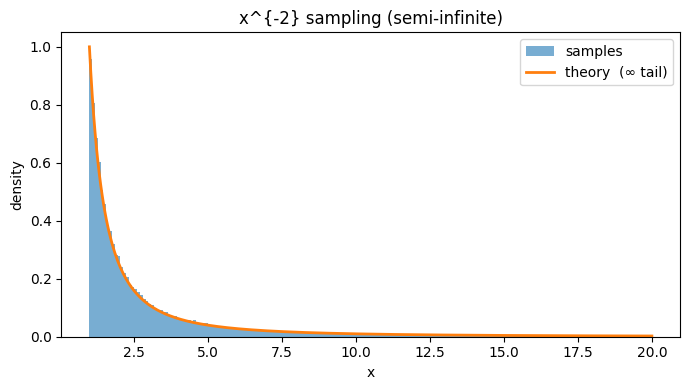

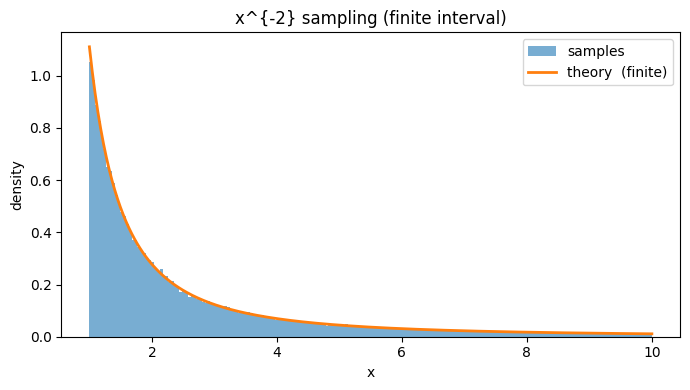

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def sample_x_inv_square(n, x_min=1.0, x_max=None, seed=None):
    """
    Draw n samples from a PDF proportional to x^{-2}.
      - If x_max is None:   p(x) = x_min * x^{-2},   x in [x_min, ∞)
      - If x_max is given:  p(x) = C * x^{-2},       x in [x_min, x_max]
           with C = 1 / (1/x_min - 1/x_max)

    Parameters
    ----------
    n : int
        Number of samples.
    x_min : float (>0)
        Lower bound of support.
    x_max : float or None
        Optional upper bound (> x_min). If None, uses semi-infinite tail.
    seed : int or None
        RNG seed for reproducibility.

    Returns
    -------
    np.ndarray
        Samples of shape (n,).
    """
    if x_min <= 0:
        raise ValueError("x_min must be > 0.")
    if x_max is not None and x_max <= x_min:
        raise ValueError("x_max must be > x_min when provided.")

    rng = np.random.default_rng(seed)
    u = rng.random(n)  # in [0,1)

    if x_max is None:
        # Inverse CDF: F^{-1}(u) = x_min / (1 - u)
        return x_min / (1.0 - u)
    else:
        # Finite-interval inverse CDF:
        # F(x) = (1/x_min - 1/x) / (1/x_min - 1/x_max)
        # => 1/x = (1-u)/x_min + u/x_max  =>  x = 1 / ((1-u)/x_min + u/x_max)
        denom = (1.0 - u) / x_min + u / x_max
        return 1.0 / denom


# Demo / quick check
if __name__ == "__main__":
    n = 100_000
    x_min = 1.0

    # --- Semi-infinite tail ---
    s_inf = sample_x_inv_square(n, x_min=x_min, seed=42)

    # Theoretical PDF for semi-infinite case: p(x) = x_min * x^{-2}
    xs = np.linspace(x_min, 20, 400)
    pdf_inf = x_min / xs**2

    plt.figure(figsize=(7,4))
    plt.hist(s_inf, bins=200, range=(x_min, 20), density=True, alpha=0.6, label="samples")
    plt.plot(xs, pdf_inf, lw=2, label="theory  (∞ tail)")
    plt.xlabel("x"); plt.ylabel("density"); plt.title("x^{-2} sampling (semi-infinite)")
    plt.legend(); plt.tight_layout()
    plt.show()

    # --- Finite interval example ---
    x_max = 10.0
    s_fin = sample_x_inv_square(n, x_min=x_min, x_max=x_max, seed=123)

    # Theoretical PDF on [x_min, x_max]
    C = 1.0 / (1.0/x_min - 1.0/x_max)
    xs2 = np.linspace(x_min, x_max, 400)
    pdf_fin = C / xs2**2

    plt.figure(figsize=(7,4))
    plt.hist(s_fin, bins=200, density=True, alpha=0.6, label="samples")
    plt.plot(xs2, pdf_fin, lw=2, label="theory  (finite)")
    plt.xlabel("x"); plt.ylabel("density"); plt.title("x^{-2} sampling (finite interval)")
    plt.legend(); plt.tight_layout()
    plt.show()


In [30]:


import numpy as np
import rebound


n=10_000
seed=42
a_min=0.1          
a_max=50.0         
e_max=0.1          
m0=1.0              

"""
Returns:
  elements: dict of arrays (a, e, inc, Omega, omega, M, f) [radians for angles]
  states:   ndarray shape (n, 6) with columns (x, y, z, vx, vy, vz)
"""
rng = np.random.default_rng(seed)
# Sample elements
a = rng.uniform(a_min, a_max, size=n)
e = rng.uniform(0.0, e_max, size=n)
inc = rng.uniform(0.0, 0.1, size=n)
Omega = rng.uniform(0.0, 2.0 * np.pi, size=n)
omega = rng.uniform(0.0, 2.0 * np.pi, size=n)
f_true = rng.uniform(0.0, 2.0 * np.pi, size=n)

# Convert M -> f (true anomaly) to get uniform-in-time sampling around each orbit

# Build a REBOUND simulation and convert to Cartesian
sim = rebound.Simulation()
#sim.G = 1.  # AU^3 / (yr^2 Msun)
sim.units=['Msun','yr','AU']
sim.add(m=m0)           # central star at origin

# Add particles by Keplerian elements relative to central mass
# (All test particles are massless by default.)

for i in range(n):
    sim.add(
        m=float(1e-7),
        a=float(a[i]),
        e=float(e[i]),
        inc=float(inc[i]),
        Omega=float(Omega[i]),
        omega=float(omega[i]),
        f=float(f_true[i])  # or use 'M=float(M[i])' if you prefer REBOUND to do the conversion
    )

# Extract Cartesian states (heliocentric ≡ barycentric here since test particles are massless)
states = np.empty((n, 7))
for i, p in enumerate(sim.particles[1:]):  # skip central mass at index 0
    #print (p.m)
    states[i, 0] = p.m    
    states[i, 1] = p.x
    states[i, 2] = p.y
    states[i, 3] = p.z
    states[i, 4] = p.vx
    states[i, 5] = p.vy
    states[i, 6] = p.vz

header = "m,x,y,z,vx,vy,vz"
np.savetxt("francesco.csv", states, delimiter=",", header=header, comments="")